# **🌲 Forest Segmentation with U-Net**
---
In this lab, we will:
✅ **Understand the U-Net architecture** for semantic segmentation  
✅ **Load the Forest Aerial dataset** (images + masks)  
✅ **Build a U-Net from scratch** in PyTorch  
✅ **Train it** to segment forest vs. non-forest pixels  
✅ **Evaluate** with Dice / IoU and **visualize predictions**  

---

## **1️⃣ What is Segmentation?**
Unlike **classification** (one label per image) or **object detection** (a box per object),
**semantic segmentation** assigns a class to **every single pixel**. 🎯

For our forest dataset this is a **binary** problem:

| Pixel value | Meaning |
|-------------|---------|
| **1 (white)** | 🌳 Forest |
| **0 (black)** | 🚫 Not forest |

So for each aerial image, the model outputs a **mask** the same size as the input — a per-pixel "forest / not forest" decision.

---

## **2️⃣ The U-Net Architecture**
U-Net is shaped like the letter **U** — hence the name. It has three parts:

🔽 **Encoder (contracting path)** → repeated *conv → conv → downsample*. Captures **context** ("what" is in the image) while shrinking spatial size.  
🔼 **Decoder (expanding path)** → repeated *upsample → conv → conv*. Recovers **location** ("where" things are) back to full resolution.  
🔗 **Skip connections** → copy feature maps from the encoder straight across to the decoder. This is the *key idea* — it lets the decoder reuse fine spatial detail that would otherwise be lost during downsampling.

```
 input ─► [enc1] ───────────────skip──────────────► [dec1] ─► output
            │                                          ▲
            ▼                                          │
          [enc2] ──────────skip─────────► [dec2] ──────┘
            │                                ▲
            ▼                                │
          [enc3] ────skip────► [dec3] ───────┘
            │                     ▲
            ▼                     │
            └──────► [bottleneck]─┘
```

### 🧩 We won't hand-code it — we'll use `segmentation_models_pytorch`
Writing U-Net from scratch is a great learning exercise, but in practice everyone uses the
**`segmentation_models_pytorch`** (**smp**) library. It gives you a battle-tested U-Net where you can
**plug in any encoder** — including **ImageNet-pretrained** backbones — with a single argument:

```python
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", ...)
```

That `encoder_name` is the interesting knob, and we'll explain it in detail below. 👇

---

#### Step 0 — (Colab only) Set the KaggleHub cache directory

In [ ]:
# # Uncomment when running on Google Colab
# import os
# os.environ["KAGGLEHUB_CACHE"] = "/content/data"

## **3️⃣ Imports & Setup**

In [1]:
# Install segmentation-models-pytorch (smp)
# !pip install -q segmentation-models-pytorch

In [26]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import tqdm
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("smp version:", smp.__version__)

Using device: cuda
smp version: 0.5.0


## **4️⃣ Downloading the Dataset**
The dataset ships as two parallel folders — **`images/`** and **`masks/`** — where each image
has a mask **with the same filename**. A `meta_data.csv` also lists the pairs.

In [4]:
import kagglehub

# Download the dataset


datasets_directory = os.path.abspath(os.path.join(".", "..","..", "Datasets"))
os.environ["KAGGLEHUB_CACHE"] = datasets_directory
path = kagglehub.dataset_download("quadeer15sh/augmented-forest-segmentation")
print("Path to dataset files:", path)

Path to dataset files: c:\Users\Raghad\Desktop\Summer-Training\Datasets\datasets\quadeer15sh\augmented-forest-segmentation\versions\2


In [5]:
# Locate the images/ and masks/ folders (paths can vary slightly by dataset version)
image_dir = glob.glob(os.path.join(path, "**", "images"), recursive=True)[0]
mask_dir  = glob.glob(os.path.join(path, "**", "masks"),  recursive=True)[0]

print("Images:", image_dir)
print("Masks :", mask_dir)

image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
mask_paths  = sorted(glob.glob(os.path.join(mask_dir,  "*.jpg")))
print(f"\nFound {len(image_paths)} images and {len(mask_paths)} masks")

Images: c:\Users\Raghad\Desktop\Summer-Training\Datasets\datasets\quadeer15sh\augmented-forest-segmentation\versions\2\Forest Segmented\Forest Segmented\images
Masks : c:\Users\Raghad\Desktop\Summer-Training\Datasets\datasets\quadeer15sh\augmented-forest-segmentation\versions\2\Forest Segmented\Forest Segmented\masks

Found 5108 images and 5108 masks


#### Let's look at an image and its mask side-by-side 👀

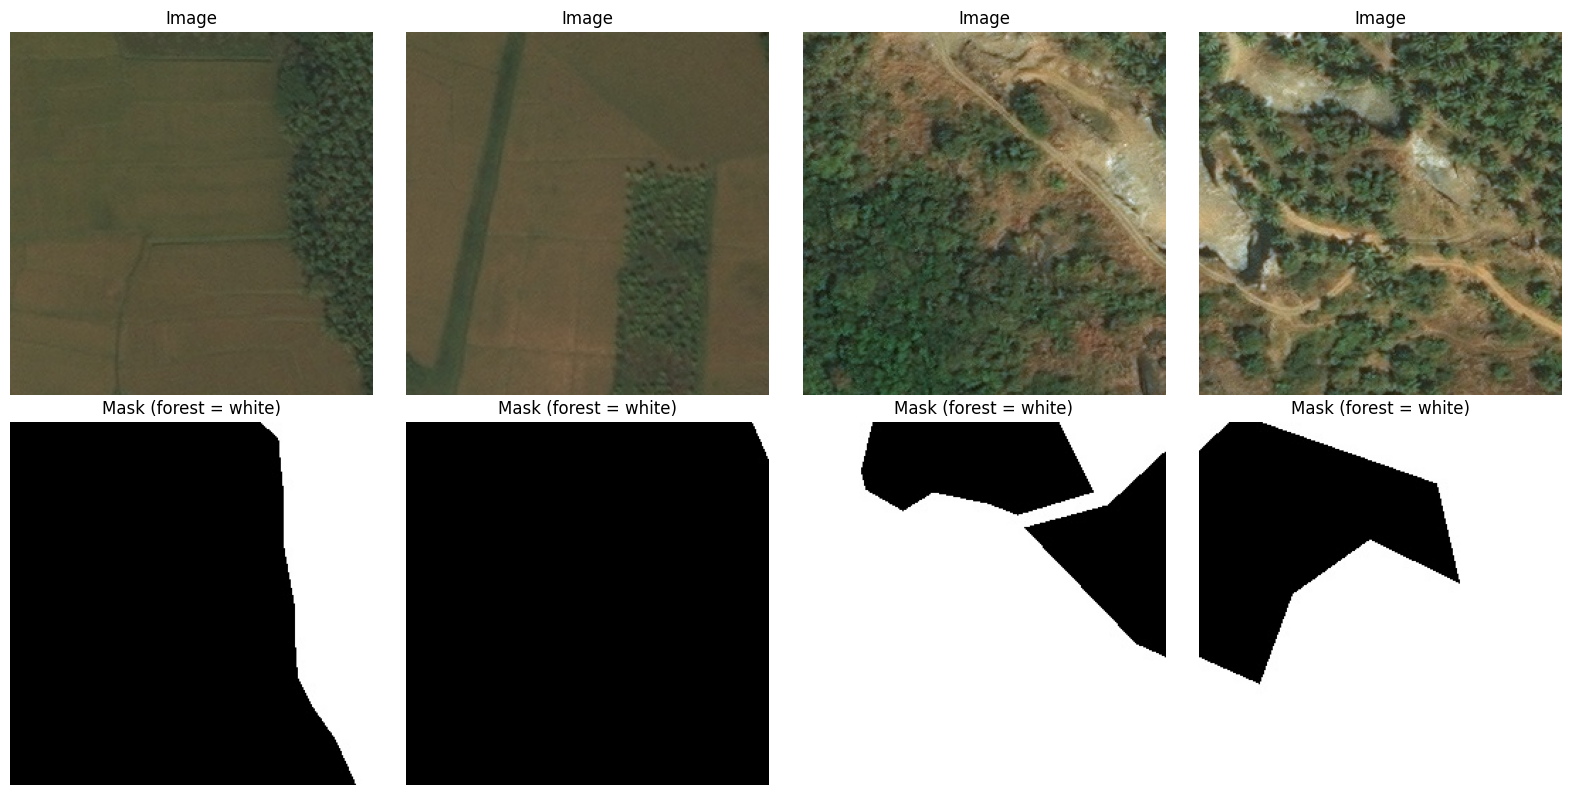

In [6]:
fig, axes = plt.subplots(2,4, figsize=(16, 8))
for i in range(4):
    img  = Image.open(image_paths[i]).convert("RGB")
    mask = Image.open(mask_paths[i]).convert("L")   # grayscale mask
    axes[0, i].imshow(img)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title("Mask (forest = white)")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## **5️⃣ Building the `Dataset`**
Our custom `Dataset` returns an **(image, mask)** pair for each index. A few important details for segmentation:

- The **image** is normalized like a normal RGB tensor.  
- The **mask** is **not** normalized — we threshold it to **{0, 1}** and keep it as a float target.  
- Image and mask are resized to the **same** `IMG_SIZE` so they stay pixel-aligned.

In [7]:
class ForestDataset(Dataset):
    def __init__(self, image_paths,image_transform,mask_transform):
        self.image_paths = image_paths
        self.mask_paths   = [ path.replace("images", "masks").replace("_sat_", "_mask_")
          for path in image_paths ]
        self.image_transform  = image_transform
        self.mask_transform  = mask_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")


        img  = self.image_transform(img)
        mask = self.mask_transform(mask)

        # Binarize the mask: forest = 1, background = 0
        mask = (mask > 0.5).float()
        return img, mask

In [8]:
IMG_SIZE = 256   # resize everything to 256x256 (keeps training fast)

# Pretrained encoders were trained on ImageNet, so we normalize with ImageNet stats.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_image_transform= transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ToTensor(),                                  # -> [0,1], shape (3,H,W)
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),      # match the pretrained encoder
])
test_image_transform= transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                                  # -> [0,1], shape (3,H,W)
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),      # match the pretrained encoder
])
mask_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                                  # -> [0,1], shape (1,H,W)
])


## **6️⃣ Train / Validation /Test Split & DataLoaders**

In [9]:
full_dataset=  sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
train_frac = 0.70
val_frac=0.15
test_frac = 0.15

val_size = int(len(full_dataset) * val_frac)
test_size = int(len(full_dataset) * test_frac)
train_size = len(full_dataset)-(val_size+test_size)

print("Dataset size:", len(full_dataset))

train_ds, val_ds ,test_ds= random_split(
    full_dataset, [train_size, val_size,test_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)


train_dataset = ForestDataset(train_ds,train_image_transform,mask_transform)
val_dataset =  ForestDataset(val_ds,test_image_transform,mask_transform)
test_dataset =  ForestDataset(test_ds, test_image_transform,mask_transform)


img, mask = train_dataset[0]
print("Image tensor:", img.shape, "| Mask tensor:", mask.shape, "| Mask values:", mask.unique())


BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {train_size} images | Val: {val_size} images | Test: {test_size} images")

imgs, masks = next(iter(train_loader))
print("Batch:", imgs.shape, masks.shape)

Dataset size: 5108
Image tensor: torch.Size([3, 256, 256]) | Mask tensor: torch.Size([1, 256, 256]) | Mask values: tensor([0., 1.])
Train: 3576 images | Val: 766 images | Test: 766 images
Batch: torch.Size([16, 3, 256, 256]) torch.Size([16, 1, 256, 256])


## **7️⃣ Building U-Net with `smp` — and Choosing an Encoder**

With smp, the whole model is **one line**. The decoder is always the U-Net expanding path;
what changes is the **encoder** (a.k.a. the **backbone**) — the network that does the downsampling
and feature extraction on the way down the "U".

```python
model = smp.Unet(
    encoder_name="resnet34",      # <-- the backbone (this is the knob we care about)
    encoder_weights="imagenet",   # start from ImageNet-pretrained weights
    in_channels=3,                # RGB input
    classes=1,                    # 1 output channel -> binary forest mask
)
```

### 🧠 What is the encoder, really?
The encoder is just a **classification network with its head chopped off**. Instead of ending in a
1000-class prediction, smp taps into the encoder's **intermediate feature maps** at several depths
and feeds them into the U-Net decoder via the **skip connections**. Because these backbones are
**pretrained on ImageNet**, they already know edges, textures, and shapes — so segmentation
converges **faster** and to **higher accuracy** than training from scratch. 🎯

### 🔬 Common encoder families
| `encoder_name` | Family | Params |
|----------------|--------|--------|
| `resnet18` | ResNet | ~11M | |
| `resnet34` | ResNet | ~21M |
| `resnet50` | ResNet | ~23M | 
| `efficientnet-b0` | EfficientNet | ~5M |
| `efficientnet-b3` | EfficientNet | ~12M | 
| `mobilenet_v2` | MobileNet | ~3M |

> ⚠️ **Two things to keep consistent when you swap encoders:**
> 1. Keep `encoder_weights="imagenet"` **and** normalize inputs with **ImageNet mean/std** (we did this in the dataset).
> 2. Bigger encoders need **more GPU memory** — if you hit OOM, lower `BATCH_SIZE` or `IMG_SIZE`.

In [10]:
# Pick your encoder here — try swapping this one word later!

model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",   # pretrained backbone
        in_channels=3,                # RGB
        classes=1,                    # single-channel forest logit
    ).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Encoder:resnet34  | Total parameters: {n_params:,}")

Encoder:resnet34  | Total parameters: 24,436,369


## **8️⃣ Loss & Metrics**
smp ships ready-made loss functions. We combine two:

- **`smp.losses.DiceLoss`** → directly optimizes **overlap** between prediction and mask (robust to the background dominating).  
- **BCE-with-logits** → per-pixel classification loss.

We still track **Dice** and **IoU** ourselves for evaluation.

> 🔧 Our model outputs **raw logits** (no sigmoid inside). smp's `DiceLoss(mode="binary")` and
> `BCEWithLogitsLoss` both expect logits, so this lines up cleanly.

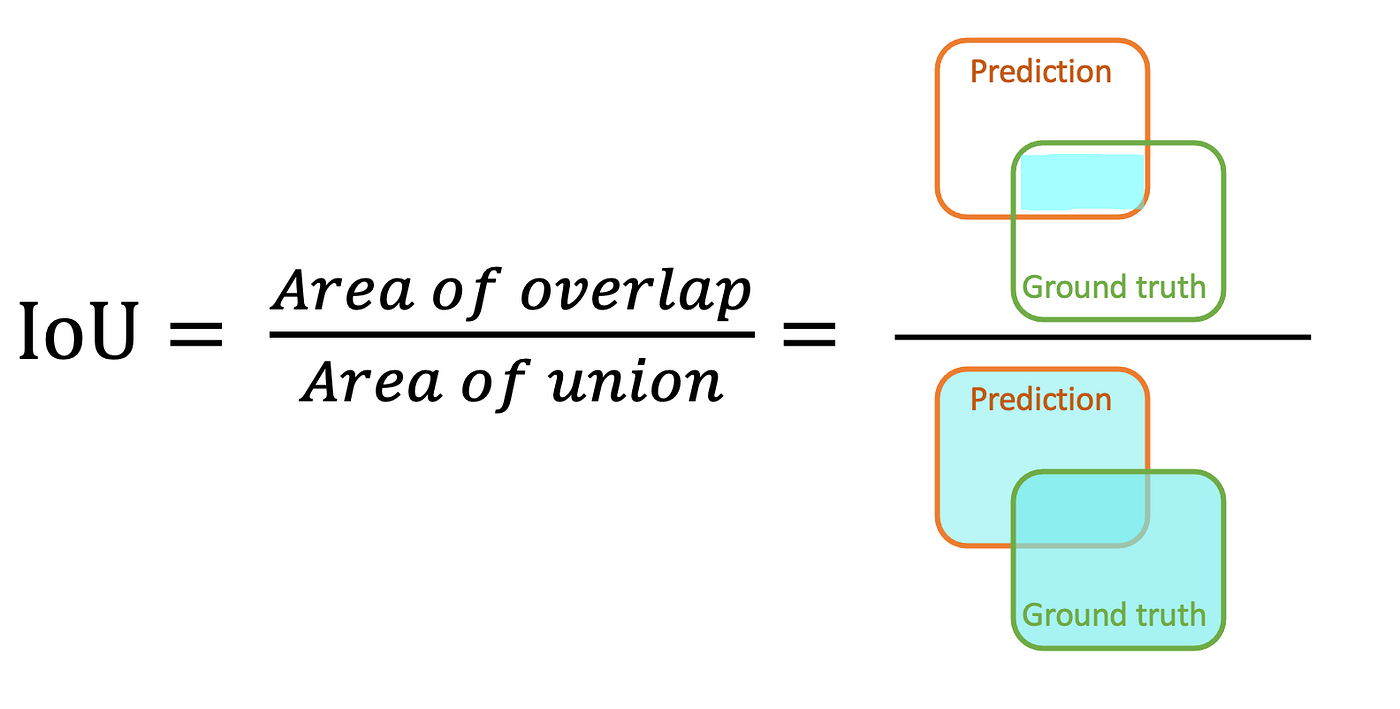
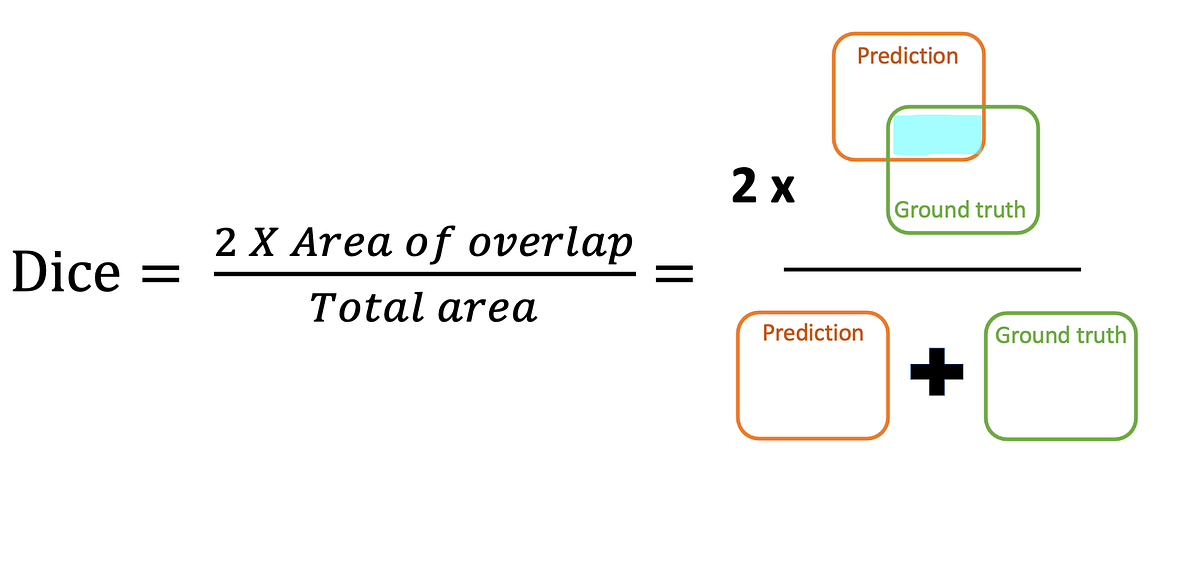


In [27]:
def dice_coeff(preds, targets, eps=1e-7):
    """preds and targets are binary {0,1} tensors."""
    preds = preds.view(-1)
    targets = targets.view(-1)
    inter = (preds * targets).sum()
    return (2 * inter + eps) / (preds.sum() + targets.sum() + eps)


def iou_score(preds, targets, eps=1e-7):
    preds = preds.view(-1)
    targets = targets.view(-1)
    inter = (preds * targets).sum()
    union = preds.sum() + targets.sum() - inter
    return (inter + eps) / (union + eps)


class DiceBCELoss(nn.Module):
    """smp DiceLoss + BCEWithLogits (both operate on raw logits)."""
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
        self.bce  = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        return self.dice(logits, targets) + self.bce(logits, targets)


criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

## **9️⃣ Training the Model**
Each epoch we run a **training pass** (update weights) and a **validation pass** (measure Dice / IoU).


In [40]:
def train_one_epoch(model, loader):
    model.train()                     # training mode (enables dropout, etc.)
    running ,dice_total,iou_total= 0.0,0.0,0.0
  
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        logits = model(images)            # 1. forward
        loss = criterion(logits, masks)  # 2. loss

        optimizer.zero_grad()              # 3. clear old gradients
        loss.backward()                    # 4. backward (compute gradients)
        optimizer.step()                   # 5. update the weights

        running += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        dice_total += dice_coeff(preds, masks).item() * imgs.size(0)
        iou_total  += iou_score(preds, masks).item()  * imgs.size(0)
             
    train_loss = running / len(loader.dataset)
    train_dice=dice_total / len(loader.dataset)
    train_iou=iou_total / len(loader.dataset)
    return train_loss,train_dice,train_iou


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running,dice_total, iou_total, n =0, 0.0, 0.0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)

        loss = criterion(logits, masks)  
        running += loss.item() * imgs.size(0)

        preds = (torch.sigmoid(logits) > 0.5).float()


        dice_total += dice_coeff(preds, masks).item() * imgs.size(0)
        iou_total  += iou_score(preds, masks).item()  * imgs.size(0)

    val_loss = running / len(loader.dataset)
    
    val_dice=dice_total / len(loader.dataset)
    val_iou=iou_total / len(loader.dataset)

    return val_loss, val_dice,val_iou


In [46]:
NUM_EPOCHS = 15
train_history = {"train_loss": [], "train_dice": [], "train_iou": []}
val_history = {"val_loss": [], "val_dice": [], "val_iou": []}

for epoch in range(NUM_EPOCHS):
    train_loss,train_dice, train_iou = train_one_epoch(model, train_loader)
    val_loss,val_dice, val_iou = evaluate(model, val_loader)

    train_history["train_loss"].append(train_loss)
    train_history["train_dice"].append(train_dice)
    train_history["train_iou"].append(train_iou)

    
    val_history["val_loss"].append(val_loss)
    val_history["val_dice"].append(val_dice)
    val_history["val_iou"].append(val_iou)
    

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} | train_Dice={train_dice:.4f} | train_IoU={train_iou:.4f} | "
          f"val_loss={val_loss:.4f} | val_Dice={val_dice:.4f} | val_IoU={val_iou:.4f}"
          )

Epoch 01/15 | train_loss=0.2811 | train_Dice=0.4349 | train_IoU=0.3850 | val_loss=0.5928 | val_Dice=0.8642 | val_IoU=0.7634
Epoch 02/15 | train_loss=0.2698 | train_Dice=0.4384 | train_IoU=0.3906 | val_loss=0.5980 | val_Dice=0.8626 | val_IoU=0.7609
Epoch 03/15 | train_loss=0.2529 | train_Dice=0.4427 | train_IoU=0.3975 | val_loss=0.6351 | val_Dice=0.8573 | val_IoU=0.7526
Epoch 04/15 | train_loss=0.2368 | train_Dice=0.4471 | train_IoU=0.4043 | val_loss=0.6175 | val_Dice=0.8648 | val_IoU=0.7641
Epoch 05/15 | train_loss=0.2289 | train_Dice=0.4488 | train_IoU=0.4072 | val_loss=0.5989 | val_Dice=0.8633 | val_IoU=0.7617
Epoch 06/15 | train_loss=0.2265 | train_Dice=0.4494 | train_IoU=0.4080 | val_loss=0.6451 | val_Dice=0.8687 | val_IoU=0.7704
Epoch 07/15 | train_loss=0.2116 | train_Dice=0.4532 | train_IoU=0.4143 | val_loss=0.7139 | val_Dice=0.8343 | val_IoU=0.7188
Epoch 08/15 | train_loss=0.2039 | train_Dice=0.4549 | train_IoU=0.4171 | val_loss=0.6454 | val_Dice=0.8634 | val_IoU=0.7621
Epoch 09

## **🔟 Training Curves**

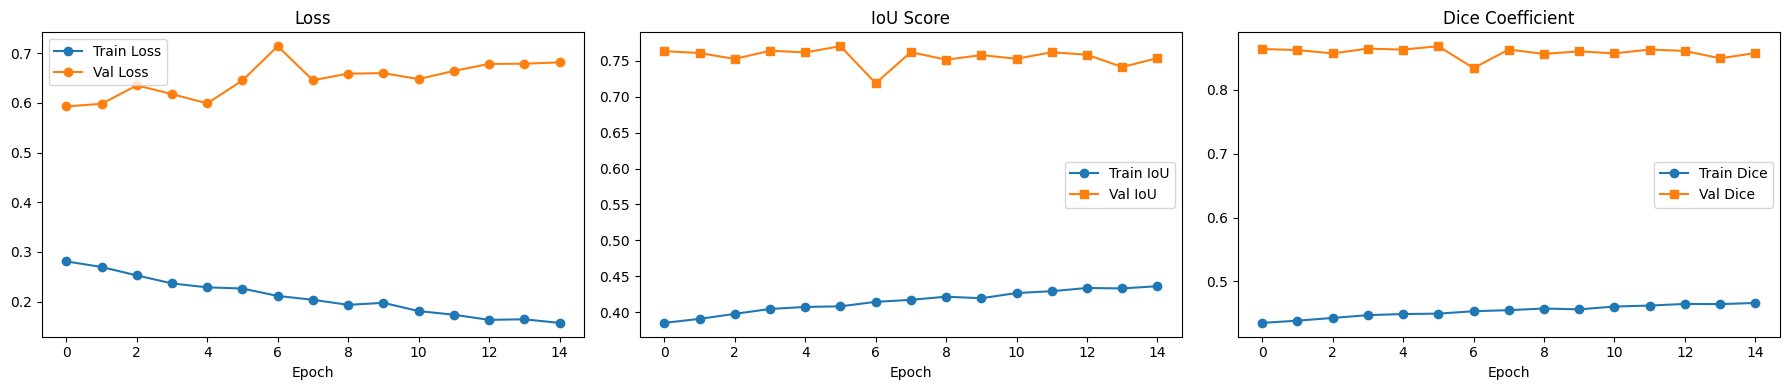

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Loss (Train vs Val)
ax[0].plot(train_history["train_loss"], marker="o", label="Train Loss")
ax[0].plot(val_history["val_loss"], marker="o", label="Val Loss")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

# Plot 2: IoU (Train vs Val)
ax[1].plot(train_history["train_iou"], marker="o", label="Train IoU")
ax[1].plot(val_history["val_iou"], marker="s", label="Val IoU")
ax[1].set_title("IoU Score")
ax[1].set_xlabel("Epoch")
ax[1].legend()

# Plot 3: Dice (Train vs Val)
ax[2].plot(train_history["train_dice"], marker="o", label="Train Dice")
ax[2].plot(val_history["val_dice"], marker="s", label="Val Dice")
ax[2].set_title("Dice Coefficient")
ax[2].set_xlabel("Epoch")
ax[2].legend()

plt.tight_layout()
plt.show()

## **1️⃣1️⃣ Inspecting Predictions**
The real test of a segmentation model is **looking at the masks**. Below we show, for a few
validation images: the **input**, the **ground-truth mask**, and the **model's prediction**.

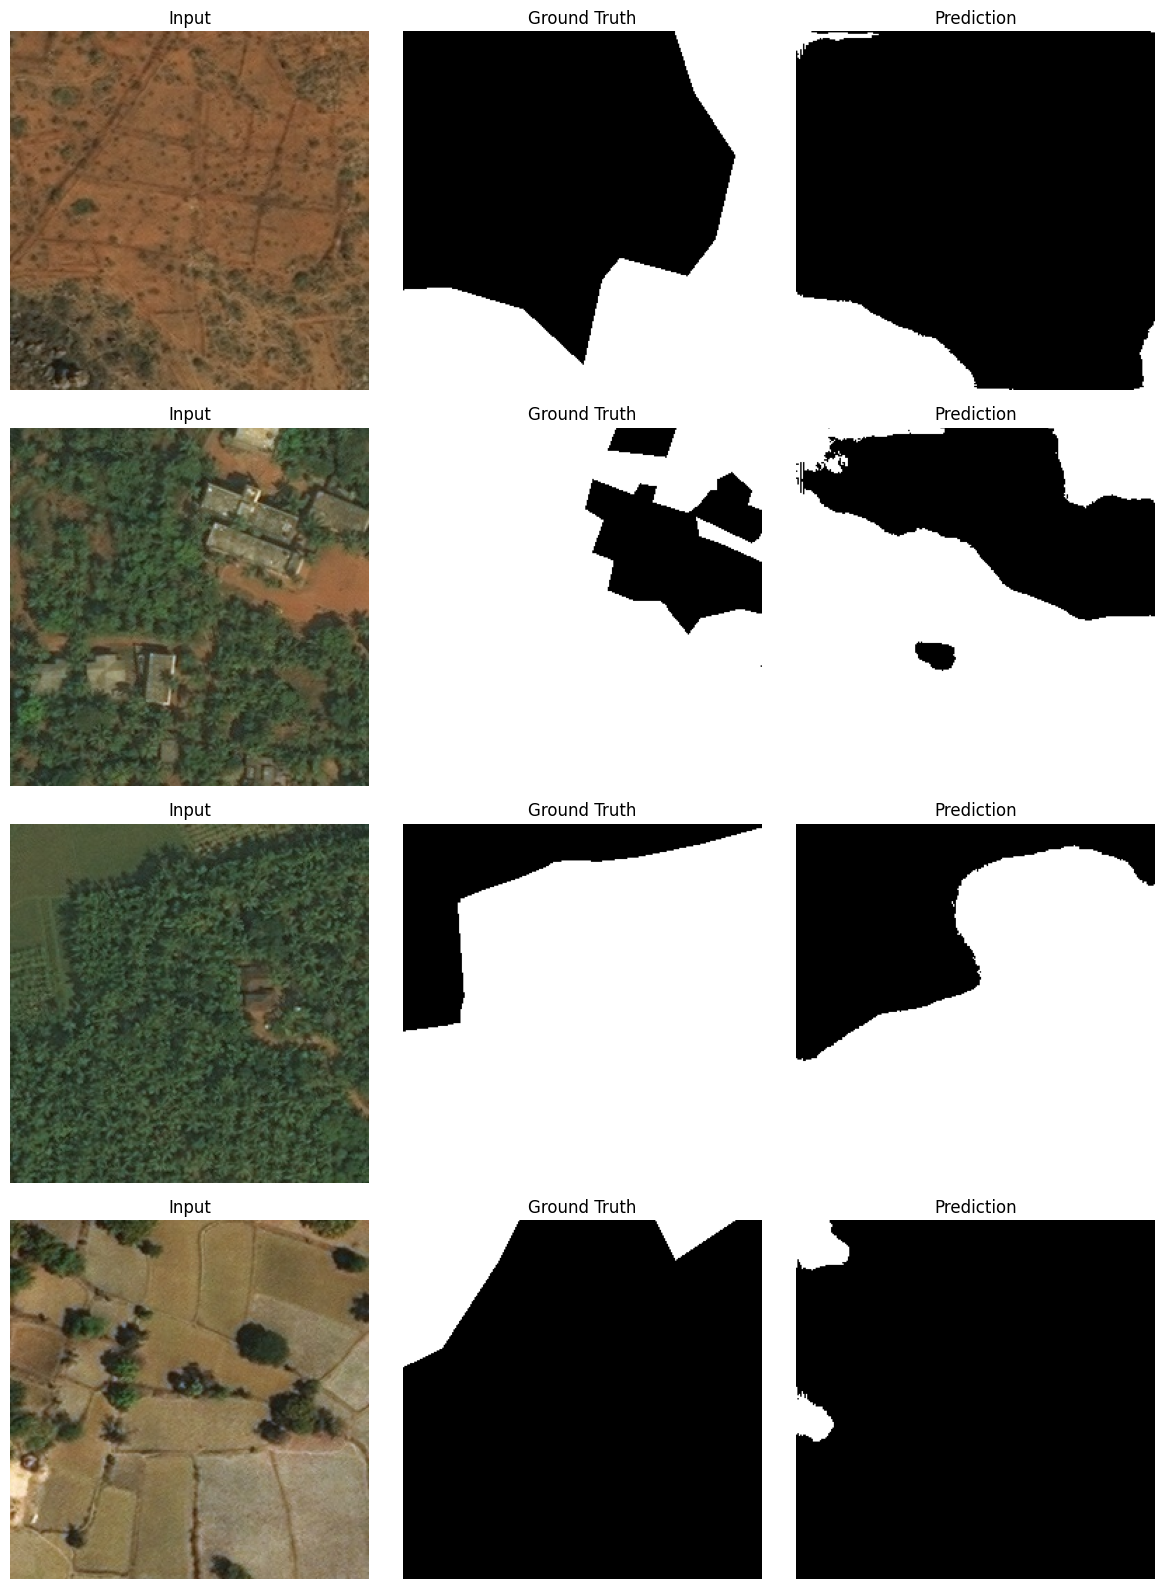

In [48]:
@torch.no_grad()
def show_predictions(model, dataset, n=4):
    model.eval()
    idxs = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    for row, idx in enumerate(idxs):
        img, mask = dataset[idx]
        logits = model(img.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze()
        mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)

        axes[row, 0].imshow(img.permute(1, 2, 0).numpy()* std + mean)
        axes[row, 0].set_title("Input"); axes[row, 0].axis("off")

        axes[row, 1].imshow(mask.squeeze(), cmap="gray")
        axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")

        axes[row, 2].imshow(pred, cmap="gray")
        axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(model, test_dataset, n=4)

## **1️⃣2️⃣ Save the Model**

In [49]:
torch.save(model.state_dict(), "unet_forest.pth")
print("✅ Saved to unet_forest.pth")

✅ Saved to unet_forest.pth
